# 17 — Plantillas: revisión del scrapeo, fantasy por temporada y diagramas de Apolonio

Este notebook contesta tres preguntas, en orden, porque cada una depende de la anterior:

1. **¿El scrapeo de plantillas está en condiciones de seguir jugadores temporada por temporada?** El panel de FBref
   (7 ligas × 16 temporadas, 61,542 filas) se armó en la Fase 7 y se usó en los notebooks 09-10 para análisis
   agregados. Seguir a *un jugador* a lo largo de su carrera exige más: saber quién es quién y juntar sus filas
   correctamente. → **Sección 1-2: auditoría y limpieza.**
2. **¿Cómo rinde cada jugador en términos fantasy, temporada por temporada?** → **Sección 3: puntos tipo FPL.**
3. **¿Quién "domina" qué tipo de perfil ofensivo en cada temporada, y cómo cambia eso?** → **Secciones 4-5:
   diagramas de Voronoi en modalidad Apolonio y su "área de dominio".**

## Dos límites que conviene tener claros desde el inicio

- **El plano de los diagramas no es la cancha.** Un Voronoi de Apolonio "en la cancha" (como el *dominant region* de
  Taki y Hasegawa) necesita la posición de cada jugador, es decir, datos de eventos o de tracking. El panel de FBref
  solo trae totales de temporada. Así que el plano aquí es un **espacio de perfil**: eje X = goles sin penal por 90,
  eje Y = asistencias por 90. La geometría es la misma; lo que cambia es qué significa "cerca".
- **El fantasy es parcial.** El panel no trae porterías a cero, goles recibidos, paradas ni bonus. El puntaje es un
  *fantasy ofensivo + disciplina* (ver sección 3). Es justo para comparar delanteros y mediocampistas entre sí, no
  para defensas y porteros.

## Qué cambia en la forma de trabajar

Los notebooks 00-16 definen toda su lógica adentro, para poder correr solos. Este es el primero que **importa** la
lógica del paquete del proyecto, `futbol_bd/` (en la raíz), que tiene pruebas automáticas en `tests/`:

| Módulo | Qué hace |
|---|---|
| `futbol_bd/plantillas.py` | carga, audita y limpia el panel; construye `id_jugador`; suma traspasos |
| `futbol_bd/fantasy.py` | esquema de puntos (FPL adaptado), percentiles, tabla de regularidad |
| `futbol_bd/apolonio.py` | Voronoi ponderado (multiplicativo / aditivo / normal), áreas, dibujo |

La razón: si la regla de "quién es quién" o "cuántos puntos vale un gol" vive copiada en varios notebooks, tarde o
temprano las copias se desincronizan (el incidente del notebook 06 en la Fase 7 fue una versión de este problema). Con
un solo lugar y pruebas (`python -m pytest tests`), un cambio que rompa algo falla antes de llegar a un análisis.

In [1]:
import sys
from pathlib import Path

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.stats import spearmanr

# El paquete del proyecto vive en la raíz (un nivel arriba de notebooks/). Se agrega esa carpeta a sys.path para
# poder importarlo sin instalarlo. La condición permite correr el notebook tanto desde notebooks/ como desde la raíz.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from futbol_bd import apolonio, fantasy, plantillas

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
FIGURAS = RAIZ / "output" / "figures"
FIGURAS.mkdir(parents=True, exist_ok=True)

# --- Estilo de las figuras ----------------------------------------------------------------------------------------
# Tintas neutras para texto y ejes: el color se reserva para los DATOS, nunca para decorar.
SUPERFICIE, TINTA, TINTA_2, TENUE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
# Colores de identidad (uno por jugador seguido). Son los 3 primeros de una paleta categórica validada para
# daltonismo: con 3 colores, cualquier par se distingue incluso con deuteranopia/protanopia.
AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
# Rampa secuencial de UN solo tono (azul claro -> oscuro) para una magnitud: los puntos fantasy. Más oscuro = más
# puntos. Un arcoíris aquí sugeriría categorías donde solo hay "más" o "menos".
RAMPA_AZUL = LinearSegmentedColormap.from_list(
    "azul", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95"])

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE, "savefig.facecolor": SUPERFICIE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": TINTA_2, "xtick.color": TENUE, "ytick.color": TENUE,
    "axes.spines.top": False, "axes.spines.right": False, "axes.titlesize": 11, "axes.titlecolor": TINTA,
    "font.size": 10, "legend.frameon": False,
})

## 1. Revisión del scrapeo de plantillas

El panel viene de las 112 tablas *Standard Stats* de jugadores de FBref (una por liga-temporada), extraídas con el
navegador porque FBref bloquea `requests` con un challenge de Cloudflare (Fase 7). Cada fila es **un jugador en un
equipo en una liga-temporada**, con partidos, titularidades, minutos, goles, asistencias, penales y tarjetas, y
desde el 2026-09-19 también el id de jugador y de equipo de FBref (`player_id`, `team_id`).

`plantillas.auditar_panel` corre todos los chequeos sobre el panel **tal como llegó** (solo convierte los minutos
"2,086" a número) y dice, para cada problema, cuántos casos encontró y qué hace la limpieza con él. El `tipo` separa:

- **error**: dato roto en la fuente → se corrige;
- **estructura**: el dato es correcto pero obliga a un paso extra (identidad, agregación);
- **contexto**: no se corrige, pero cambia cómo se interpreta (temporadas recortadas).

In [2]:
cruda = plantillas.cargar_panel_crudo()
print(f"Panel crudo: {cruda.shape[0]:,} filas × {cruda.shape[1]} columnas — "
      f"{cruda['league'].nunique()} ligas, {cruda['season'].nunique()} temporadas "
      f"({cruda['season'].min()} a {cruda['season'].max()})")

auditoria = plantillas.auditar_panel(cruda)
auditoria

Panel crudo: 61,542 filas × 28 columnas — 7 ligas, 16 temporadas (2010-2011 a 2025-2026)


,chequeo,tipo,casos,ejemplo,accion
0,fila duplicada (mismo contenido),error,1,"Emanuele Torrasi, Milan, Serie A, 2017-2018",se elimina la copia
1,minutos vacíos,error,1,"Odysseus Velanas, Utrecht, Eredivisie, 2018-2019",0 si `minutes_90s` = 0 (entró sin sumar minutos)
2,"otro conteo vacío (asistencias, penales)",error,38,"Petar Filipović, St Pauli, Bundesliga, 2010-2011",se rellena con 0
3,G+A no cuadra con goles + asistencias,error,33,"Petar Filipović, St Pauli, Bundesliga, 2010-2011",todas las columnas derivadas se recalculan des...
4,goles sin penal no cuadra con goles − penales,error,3,"Odysseus Velanas, Utrecht, Eredivisie, 2018-2019",se recalcula
5,más penales anotados que intentados,error,1,"Mario Lemina, Juventus, Serie A, 2015-2016","intentos = max(intentos, anotados)"
6,fila sin id de FBref,error,0,,se usa la clave por nombre en todo el panel
7,jugador sin página en FBref (id = su nombre),contexto,43,"Quim Kruijsen, VVV-Venlo, Eredivisie, 2010-2011",se usa ese id; marcado en `id_provisional`
8,mismo nombre con 2+ años de nacimiento en una ...,estructura,98,Jonas Hofmann (Bundesliga 2019-2020) / David L...,"el id es el de FBref, no el nombre"
9,"nombre + año + nacionalidad iguales, 2 personas",estructura,4,"Adriano, Borja García, Fernandinho, Vitinha",el id de FBref los separa


### Qué significa cada hallazgo

**Errores de la fuente (pocos, pero cada uno rompe un cálculo):**

- *1 fila duplicada* (Emanuele Torrasi, Milan 2017-18): mismo contenido, pero distinto número de fila y distinto id
  de FBref (ver "Identidad" abajo), por eso un `drop_duplicates()` simple no la detectaba.
- *1 fila con minutos vacíos*, *38 con otro conteo vacío* (casi todas asistencias en temporadas viejas de la
  Bundesliga) y las columnas derivadas que no cuadran (*33* G+A, *3* goles sin penal): la limpieza rellena los conteos
  con 0 y **recalcula todas las columnas derivadas** desde los conteos, en vez de confiar en la columna scrapeada.
- *1 penal anotado sin intento* (Mario Lemina, Juventus 2015-16): se corrige el intento, no el gol.

**Identidad — el problema de fondo.** El scrapeo original solo guardó el nombre, y el nombre no alcanza: 98 veces
aparece el mismo nombre con dos años de nacimiento distintos *en la misma liga y temporada* (p. ej. dos "Rodri" en La
Liga 2010-11). La primera solución fue una clave nombre + año de nacimiento + nacionalidad, pero sabíamos que podía
juntar homónimos. Por eso el 2026-09-19 se volvieron a pedir las 112 tablas a FBref para agregar el **id de jugador y
de equipo de FBref** (`scripts/fbref_extraer_tabla.js` + `scripts/unir_ids_fbref.py`). Se verificó fila por fila que
fueran las mismas tablas: 90 idénticas y 22 con cambios menores de FBref (el PSG ahora se llama "Paris SG", un
jugador renombrado, filas en otro orden), sin ningún número distinto.

Comparar la clave por nombre contra los ids de FBref fue revelador — hubo errores en **los dos sentidos**:

- la clave por nombre **juntaba a 4 pares de personas distintas** con mismo nombre, año y nacionalidad: Vitinha (el
  del PSG y un delantero de Marsella/Genoa: la Ligue 1 2023-24 le sumaba 46 partidos a "uno" en 34 jornadas),
  Fernandinho, Adriano y Borja García;
- pero FBref también se equivoca: tiene **2 jugadores con perfil duplicado** (misma persona, dos ids). Édgar Méndez
  aparece como "Edgar Mendez" en Almería 2014-15 y Cruz Azul 2017-18, y como "Édgar Méndez" en el resto de su carrera
  — las temporadas se intercalan en una sola trayectoria. Emanuele Torrasi aparece dos veces en el Milan 2017-18 con
  la misma fila: es el "duplicado" de arriba.

El id final es el de FBref con esos 2 perfiles unidos (`ALIAS_FBREF`). `candidatos_revision` lista todos los casos
dudosos y cómo quedó resuelto cada uno; si un scrapeo futuro trae uno nuevo, aparece como "PENDIENTE de revisar":

In [3]:
display(plantillas.candidatos_revision(cruda))

limpio = plantillas.limpiar_panel(cruda)
# Control de calidad del id final: ningún jugador puede sumar más partidos de los que caben en una temporada.
print("Ids con más partidos de los posibles:", len(plantillas.detectar_colisiones(limpio)))
print("Jugadores sin página en FBref (id provisional = su nombre):",
      limpio.loc[limpio["id_provisional"], "id_jugador"].nunique())

,clave_por_nombre,player_id,jugador,equipos,desde,hasta,posicion,estado
0,adriano|1982|BRA,4ec73d8a,Adriano,Roma,2010-2011,2010-2011,FW,homónimos verificados
1,adriano|1982|BRA,e9350581,Adriano,Monaco,2010-2011,2010-2011,DF,homónimos verificados
2,borja-garcia|1990|ESP,13c3bec9,Borja García,Racing Sant,2011-2012,2011-2012,DF,homónimos verificados
3,borja-garcia|1990|ESP,e7f4603c,Borja García,Córdoba / Girona / Huesca,2014-2015,2022-2023,"FW,MF",homónimos verificados
4,edgar-mendez|1990|ESP,aed746df,Édgar Méndez,Granada / Alavés / Cruz Azul / Necaxa,2015-2016,2023-2024,"MF,FW",alias (misma persona)
5,edgar-mendez|1990|ESP,f5e19d23,Edgar Mendez,Almería / Cruz Azul,2014-2015,2017-2018,MF,alias (misma persona)
6,emanuele-torrasi|1999|ITA,06378dd2,Emanuele Torrasi,Milan,2017-2018,2017-2018,MF,alias (misma persona)
7,emanuele-torrasi|1999|ITA,16bc48f8,Emanuele Torrasi,Milan,2017-2018,2017-2018,MF,alias (misma persona)
8,fernandinho|1985|BRA,101da2b5,Fernandinho,Manchester City,2013-2014,2021-2022,"DF,MF",homónimos verificados
9,fernandinho|1985|BRA,2fdf41ef,Fernandinho,Hellas Verona,2014-2015,2014-2015,"FW,MF",homónimos verificados


Ids con más partidos de los posibles: 0
Jugadores sin página en FBref (id provisional = su nombre): 40


**Traspasos.** 2,088 veces un jugador aparece en dos equipos de la misma liga-temporada (se fue a mitad de temporada).
Para hablar de "su temporada" hay que sumar esas filas → `agregar_por_temporada`. Los traspasos **entre** ligas
(1,046) se dejan como filas separadas, una por liga, porque los percentiles se calculan dentro de cada liga.

**Temporadas recortadas.** Eredivisie, Ligue 1 y Liga MX 2019-20 se cortaron por COVID (26-28 partidos). Por eso los
puntos se normalizan por jornada disputada en la liga (`pts_por_jornada`) y no se comparan totales crudos entre
temporadas.

## 2. De jugador-equipo a jugador-temporada

In [4]:
jt = plantillas.agregar_por_temporada(limpio)
print(f"Filas jugador-equipo-temporada (limpio): {len(limpio):,}")
print(f"Filas jugador-liga-temporada:            {len(jt):,}  ({len(limpio) - len(jt):,} filas de traspasos sumadas)")
print(f"Jugadores distintos (id_jugador):        {jt['id_jugador'].nunique():,}")

# Ejemplo concreto: los traspasos dentro de la Liga MX en 2025-26 con más minutos. `equipos` lista los clubes del de
# más minutos al de menos, y `pct_minutos` es la proporción de los minutos posibles de la temporada que jugó.
(jt[(jt["league"] == "Liga MX") & (jt["season"] == "2025-2026") & (jt["n_equipos"] > 1)]
 .nlargest(5, "minutes")[["player", "equipos", "games", "minutes", "goals", "assists", "pct_minutos"]].round(2))

Filas jugador-equipo-temporada (limpio): 61,541
Filas jugador-liga-temporada:            59,452  (2,089 filas de traspasos sumadas)
Jugadores distintos (id_jugador):        16,307


,player,equipos,games,minutes,goals,assists,pct_minutos
32824,Ricardo Gutiérrez,Puebla / Mazatlán,34,3060,0.0,0.0,1.0
32368,Agustín Palavecino,Necaxa / Cruz Azul,32,2668,7.0,5.0,0.87
32896,Uroš Đurđević,Atlas / Monterrey,31,2541,12.0,1.0,0.83
32676,José Iván Rodríguez,Necaxa / León,31,2442,0.0,0.0,0.8
32477,Diber Cambindo,León / Necaxa,31,2315,14.0,4.0,0.76


## 3. Puntos tipo fantasy por temporada

Se usa el reglamento de **Fantasy Premier League (FPL)** como referencia porque es el más jugado y es público. Lo que
se puede aplicar con totales de temporada, y lo que no:

| Regla FPL | Aquí |
|---|---|
| Jugar ≥60 min: 2 pts · <60 min: 1 pt | titular = 2, suplente que entra = 1 (aproximación: no hay minutos por partido) |
| Gol: portero/defensa 6 · medio 5 · delantero 4 | según la posición principal de FBref |
| Asistencia 3 · amarilla −1 · roja −3 · penal fallado −2 | igual |
| Portería a cero, goles recibidos, paradas, bonus | **no disponible** en el panel |

Tres formas de expresar el rendimiento, cada una para una pregunta distinta:

- `pts_total`: los puntos de la temporada (lo que sumarías en tu equipo fantasy).
- `pts_por_jornada`: puntos / jornadas de la liga. Compara temporadas de 34, 38 o 28 jornadas y castiga perderse
  partidos, igual que un fantasy real.
- `pct_pts_jornada`: el **percentil** de `pts_por_jornada` dentro de su liga-temporada-posición, entre jugadores con
  900+ minutos. Es la métrica para **seguir a un jugador entre temporadas y ligas**: ser percentil 95 significa lo
  mismo en la Premier de 2013 que en la Liga MX de 2025, aunque el ambiente goleador sea distinto.

In [5]:
jt = fantasy.puntos_fantasy(jt)
jt["pct_pts_jornada"] = fantasy.percentil_en_grupo(jt, "pts_por_jornada")

# Prueba de sentido común: las mejores temporadas fantasy del panel completo deberían ser temporadas históricas
# conocidas. Si aquí apareciera un suplente de la Eredivisie, algo estaría mal en la agregación o en el esquema.
columnas = ["player", "league", "season", "pos_principal", "goals", "assists",
            "pts_aparicion", "pts_goles", "pts_asistencias", "pts_total", "pts_por_jornada"]
jt.nlargest(10, "pts_total")[columnas].round(2)

,player,league,season,pos_principal,goals,assists,pts_aparicion,pts_goles,pts_asistencias,pts_total,pts_por_jornada
16326,Lionel Messi,La Liga,2011-2012,FW,50.0,16.0,73,200.0,48.0,313.0,8.24
17719,Cristiano Ronaldo,La Liga,2014-2015,FW,48.0,16.0,70,192.0,48.0,298.0,7.84
17932,Lionel Messi,La Liga,2014-2015,FW,43.0,18.0,75,172.0,54.0,295.0,7.76
16100,Cristiano Ronaldo,La Liga,2011-2012,FW,46.0,12.0,75,184.0,36.0,289.0,7.61
16861,Lionel Messi,La Liga,2012-2013,FW,46.0,11.0,60,184.0,33.0,276.0,7.26
49606,Mohamed Salah,Premier League,2024-2025,MF,29.0,18.0,76,145.0,54.0,274.0,7.21
18461,Luis Suárez,La Liga,2015-2016,FW,40.0,17.0,70,160.0,51.0,270.0,7.11
15542,Cristiano Ronaldo,La Liga,2010-2011,FW,40.0,9.0,66,160.0,27.0,251.0,6.61
36190,Zlatan Ibrahimović,Ligue 1,2015-2016,FW,38.0,13.0,60,152.0,39.0,248.0,6.53
15778,Lionel Messi,La Liga,2010-2011,FW,31.0,19.0,64,124.0,57.0,242.0,6.37


Pasa la prueba: el top-10 histórico son las temporadas de Messi (50 goles en 2011-12, 313 pts) y Cristiano en La
Liga, Luis Suárez 2015-16, Zlatan 2015-16 y Salah 2024-25, el único de la Premier. Salah aparece como `MF` esa
temporada (así lo clasificó FBref), por eso cada gol le vale 5 y no 4 — coincide con FPL, donde también está listado
como mediocampista. La posición importa: con el mismo número de goles, un medio suma 25% más que un delantero.

In [6]:
# ¿Qué tan parejo es el puntaje entre posiciones? Puntos por jornada de los jugadores con 900+ minutos en la última
# temporada completa (2025-26), las 7 ligas juntas.
ultima = jt[(jt["season"] == "2025-2026") & (jt["minutes"] >= 900)]
(ultima.groupby("pos_principal")["pts_por_jornada"].describe()[["count", "25%", "50%", "75%", "max"]]
 .rename(columns={"count": "jugadores", "25%": "p25", "50%": "mediana", "75%": "p75"}).round(2))

,jugadores,p25,mediana,p75,max
pos_principal,,,,,
DF,726.0,1.11,1.44,1.79,3.21
FW,294.0,1.54,2.12,2.71,6.24
GK,160.0,1.13,1.65,1.86,2.09
MF,962.0,1.34,1.76,2.29,5.26


Aquí se ve el sesgo del esquema parcial. Los porteros no pasan de 2.09 pts por jornada: ese máximo es literalmente
"jugar de titular todos los partidos" (2 pts cada uno), porque no hay porterías a cero ni paradas que sumar. La
mediana de los defensas (1.44) queda por debajo de la de medios (1.76) y delanteros (2.12). En FPL real, un defensa o
portero titular de un equipo sólido suma además 40-60 pts por temporada solo en porterías a cero (4 pts × 10-15
porterías).

Conclusión práctica: **comparar solo dentro de la misma posición** (por eso el percentil se calcula por
liga-temporada-posición) y dejar a defensas y porteros fuera de los diagramas hasta tener datos defensivos (sección 6).

In [7]:
LIGA = "Liga MX"
desglose = ["pts_aparicion", "pts_goles", "pts_asistencias", "pts_tarjetas", "pts_penales", "pts_total"]
(jt[(jt["league"] == LIGA) & (jt["season"] == "2025-2026") & jt["pos_principal"].isin(fantasy.POSICIONES_ATAQUE)]
 .nlargest(10, "pts_total")[["player", "equipos", "pos_principal", "minutes"] + desglose + ["pct_pts_jornada"]]
 .round(1))

,player,equipos,pos_principal,minutes,pts_aparicion,pts_goles,pts_asistencias,pts_tarjetas,pts_penales,pts_total,pct_pts_jornada
32685,João Pedro,Atlético San Luis,FW,3029,68,104.0,3.0,-9,-0.0,166.0,100.0
32419,Armando González,Guadalajara,FW,2381,64,96.0,6.0,-3,-2.0,161.0,96.8
32915,Ángel Correa,UANL,MF,2737,62,70.0,36.0,-6,-2.0,160.0,100.0
32686,Juan Brunetta,UANL,MF,2500,61,75.0,21.0,-6,-0.0,151.0,99.2
32704,Kevin Castañeda,Tijuana,MF,2697,67,60.0,18.0,-5,-2.0,138.0,98.4
32427,Brian Rodríguez,América,MF,2230,60,65.0,18.0,-4,-2.0,137.0,97.7
32801,Paulinho,Toluca,FW,2018,50,72.0,12.0,-4,-0.0,130.0,93.5
32681,José Paradela,Cruz Azul,MF,2494,66,45.0,24.0,-4,-2.0,129.0,96.9
32880,Sergio Canales,Monterrey,MF,2139,51,60.0,15.0,-3,-4.0,119.0,96.1
32591,Ismael Díaz,León,MF,1927,49,50.0,18.0,0,-0.0,117.0,95.3


### Regularidad: rendir todos los años, no uno

Un fantasy premia al jugador que suma **cada** temporada. `tabla_consistencia` resume la carrera de cada jugador
con su percentil medio, su peor y mejor temporada y la dispersión (desviación estándar del percentil). Se usa el
percentil, no los puntos, para que temporadas de ligas y épocas distintas pesen igual.

In [8]:
atacantes = jt[jt["pos_principal"].isin(fantasy.POSICIONES_ATAQUE)]

print("Todas las ligas — atacantes con 6+ temporadas elegibles (900+ min):")
display(fantasy.tabla_consistencia(atacantes, min_temporadas=6).head(12).round(1))

print(f"{LIGA} — atacantes con 4+ temporadas elegibles:")
display(fantasy.tabla_consistencia(atacantes[atacantes["league"] == LIGA], min_temporadas=4).head(12).round(1))

Todas las ligas — atacantes con 6+ temporadas elegibles (900+ min):


,jugador,posicion,temporadas,ligas,pct_medio,pct_min,pct_max,pct_desv,desde,hasta
id_jugador,,,,,,,,,,
dea698d9,Cristiano Ronaldo,FW,12,La Liga / Premier League / Serie A,97.9,93.3,100.0,2.0,2010,2021
d70ce98e,Lionel Messi,FW,13,La Liga / Ligue 1,97.3,76.9,100.0,6.3,2010,2022
42fd9c7f,Kylian Mbappé,FW,10,La Liga / Ligue 1,96.6,83.3,100.0,6.4,2016,2025
21a66f6a,Harry Kane,FW,12,Bundesliga / Premier League,95.9,80.4,100.0,6.6,2014,2025
8d78e732,Robert Lewandowski,FW,16,Bundesliga / La Liga,95.0,54.3,100.0,12.1,2010,2025
6e44569a,Guus Til,MF,7,Eredivisie,93.9,85.0,98.4,5.4,2017,2025
aed3a70f,Ollie Watkins,FW,6,Premier League,92.6,85.0,100.0,5.1,2020,2025
54e4866f,Vincenzo Grifo,MF,9,Bundesliga,92.3,75.2,100.0,7.9,2016,2025
1f44ac21,Erling Haaland,FW,7,Bundesliga / Premier League,92.2,64.1,100.0,12.6,2019,2025


Liga MX — atacantes con 4+ temporadas elegibles:


,jugador,posicion,temporadas,ligas,pct_medio,pct_min,pct_max,pct_desv,desde,hasta
id_jugador,,,,,,,,,,
d60099bc,Juan Brunetta,MF,4,Liga MX,98.0,94.8,100.0,2.3,2022,2025
8a3d080a,Daniel Ludueña,MF,5,Liga MX,91.0,82.6,100.0,7.2,2010,2014
d717b80e,Alejandro Zendejas,MF,6,Liga MX,89.9,81.8,97.4,5.9,2020,2025
5535c728,Julián Quiñones,FW,5,Liga MX,87.8,66.8,98.3,13.4,2017,2023
284e865d,Mauro Boselli,FW,6,Liga MX,87.3,47.7,100.0,19.7,2013,2018
dc7acc74,Jean Meneses,MF,6,Liga MX,87.2,66.8,99.1,14.4,2018,2023
8748ef78,Ismael Sosa,MF,6,Liga MX,86.8,51.4,100.0,18.0,2014,2020
d0846b6c,Jesús Gallardo,MF,5,Liga MX,86.2,77.2,93.4,6.5,2016,2021
e97a88da,Christian Giménez,MF,7,Liga MX,85.9,69.2,100.0,12.0,2010,2016


En el panel completo, la tabla reproduce la jerarquía conocida — Cristiano con percentil medio 97.9 en 12 temporadas
y 3 ligas, sin bajar nunca del 93 — y eso da confianza en la métrica. La dispersión (`pct_desv`) separa perfiles que
el promedio iguala: Salah tiene percentil medio 91, pero con una temporada en el 29; Guus Til tiene casi el mismo
promedio (94) con un piso de 85.

En la Liga MX, **Juan Brunetta** tiene el percentil medio más alto entre los atacantes con 4+ temporadas elegibles
(98.0, de 2022-23 a 2025-26) y ninguna temporada por debajo del 94.8. Es el jugador que se sigue en las figuras de
abajo.

## 4. Diagramas de Voronoi en modalidad Apolonio

### La geometría

Un **Voronoi normal** reparte el plano entre varios puntos (sitios): cada lugar pertenece al sitio más cercano. Todos
valen igual y las fronteras son rectas (mediatrices).

En la versión **ponderada** cada sitio tiene un peso $w_i$ y los de más peso "alcanzan" más lejos. Hay dos formas
clásicas de meter el peso, y ambas llevan el nombre de Apolonio:

| modo | un punto $x$ pertenece al sitio que minimiza | frontera entre dos sitios |
|---|---|---|
| **multiplicativo** | $d(x, p_i)\,/\,w_i$ | **círculo de Apolonio**: el lugar donde $d_i / d_j = w_i / w_j$ es un círculo que encierra al sitio más débil |
| **aditivo** | $d(x, p_i) - w_i$ | rama de **hipérbola**; es el "diagrama de Apolonio" de la geometría computacional (CGAL) |

El multiplicativo es el que se conoce en fútbol: en el *dominant region* de Taki y Hasegawa el peso es la velocidad
del jugador y $d/w$ es el tiempo que tarda en llegar a cada punto de la cancha.

Para dos sitios con $k = w_{débil}/w_{fuerte} < 1$, el círculo de Apolonio tiene centro $(a - k^2 b)/(1 - k^2)$ y
radio $k\,|a-b|/(1-k^2)$ (con $a$ el débil y $b$ el fuerte). La prueba `tests/test_apolonio.py` verifica que el
diagrama calculado coincide con esta fórmula píxel por píxel.

### Cómo se traduce al fútbol en este notebook

- **Sitios**: los 20 atacantes (delanteros y medios) con más puntos fantasy de cada temporada, con 900+ minutos.
- **Plano**: su perfil ofensivo — X = goles sin penal por 90, Y = asistencias por 90. Arriba a la izquierda están los
  creadores, abajo a la derecha los rematadores, arriba a la derecha los que hacen las dos cosas.
- **Peso**: los puntos fantasy de la temporada.
- **Celda de un jugador**: los perfiles para los que él es la referencia dominante — combina *parecido* (distancia)
  con *producción* (peso). Un jugador con muchos puntos se queda con perfiles que están lejos de él; uno con pocos,
  solo con un círculo a su alrededor.

**Por qué el multiplicativo como modo principal:** es invariante a la escala del peso (multiplicar todos los puntos por
10 no cambia nada), así que se usan los puntos tal cual, sin inventar una constante. El aditivo obliga a convertir
puntos en distancia con un parámetro (`alcance`) y el dibujo depende de esa elección; se muestra para comparar.

In [9]:
# --- Parámetros del mapa ------------------------------------------------------------------------------------------
N_SITIOS = 20        # atacantes por temporada; con muchos más, las celdas se vuelven ilegibles
MIN_MINUTOS = 900    # mismo umbral que los percentiles: por debajo, las tasas por 90 son sobre todo ruido
EJE_X, EJE_Y = "goals_pens_per90", "assists_per90"
ETIQUETA_X, ETIQUETA_Y = "Goles sin penal por 90 min", "Asistencias por 90 min"
RESOLUCION = 500     # píxeles por lado para dibujar (las áreas de la sección 5 usan 300; el error es < 1%)

elegibles = jt[(jt["league"] == LIGA) & jt["pos_principal"].isin(fantasy.POSICIONES_ATAQUE)
               & (jt["minutes"] >= MIN_MINUTOS)]
sitios = (elegibles.sort_values("pts_total", ascending=False).groupby("season").head(N_SITIOS)
          .sort_values(["temporada_inicio", "pts_total"], ascending=[True, False]).reset_index(drop=True))

# Dominio FIJO para toda la liga: de 0 al máximo (+5%) de TODAS las temporadas. Así un mismo perfil cae en el mismo
# lugar en cualquier panel, y las áreas de temporadas distintas se pueden comparar.
X_MAX = sitios[EJE_X].max() * 1.05
Y_MAX = sitios[EJE_Y].max() * 1.05
# La distancia se mide con cada eje llevado a [0, 1]. Sin esto, el eje con números más grandes (goles/90 llega a ~1,
# asistencias/90 a ~0.6) pesaría más en la distancia solo por sus unidades.
sitios["u"] = apolonio.escalar(sitios[EJE_X], 0, X_MAX)
sitios["v"] = apolonio.escalar(sitios[EJE_Y], 0, Y_MAX)

# El color de las celdas usa la MISMA escala en todas las temporadas: un azul dado significa los mismos puntos en
# cualquier panel.
NORM = Normalize(sitios["pts_total"].min(), sitios["pts_total"].max())
print(f"{len(sitios)} sitios = {sitios['season'].nunique()} temporadas × {N_SITIOS} atacantes")
print(f"Dominio: {ETIQUETA_X} de 0 a {X_MAX:.2f} · {ETIQUETA_Y} de 0 a {Y_MAX:.2f}")
print(f"Puntos de los sitios: de {sitios['pts_total'].min():.0f} a {sitios['pts_total'].max():.0f}")

# Jugadores a seguir: los 3 que más veces entraron al top-20 en las últimas 6 temporadas (desempate: más puntos).
ULTIMAS = sorted(sitios["temporada_inicio"].unique())[-6:]
focos = (sitios[sitios["temporada_inicio"].isin(ULTIMAS)]
         .groupby("id_jugador").agg(jugador=("player", "first"), temporadas_top20=("season", "size"),
                                    puntos=("pts_total", "sum"))
         .sort_values(["temporadas_top20", "puntos"], ascending=False).head(3))
# Un color fijo por jugador en todas las figuras: el color sigue a la persona, no a su lugar en un ranking.
COLOR_FOCO = dict(zip(focos.index, [NARANJA, AZUL, AQUA]))
focos

320 sitios = 16 temporadas × 20 atacantes
Dominio: Goles sin penal por 90 min de 0 a 1.09 · Asistencias por 90 min de 0 a 0.63
Puntos de los sitios: de 82 a 185


,jugador,temporadas_top20,puntos
id_jugador,,,
d60099bc,Juan Brunetta,4,572.0
585e1b85,André-Pierre Gignac,4,454.0
0cab947b,Nicolás Ibáñez,4,434.0


In [10]:
def celdas(d, modo="multiplicativo", resolucion=RESOLUCION, alcance=0.15):
    """Etiqueta el dominio [0, 1]² entre los sitios de UNA temporada (`d`) según el modo.

    - multiplicativo: pesos = puntos fantasy tal cual (el modo es invariante a la escala).
    - aditivo: los puntos se convierten a distancia; el mejor del grupo recibe `alcance` (0.15 = 15% del lado del
      dominio) y el peor 0.
    - voronoi: sin pesos (línea base: solo cuenta la posición).
    """
    xy = d[["u", "v"]].to_numpy()
    if modo == "multiplicativo":
        pesos = d["pts_total"].to_numpy()
    elif modo == "aditivo":
        pesos = apolonio.pesos_aditivos(d["pts_total"].to_numpy(), alcance)
    else:
        pesos = None
    return apolonio.etiquetar(xy, pesos, modo=modo, resolucion=resolucion)


def nombre_corto(nombre):
    """'João Pedro' se queda completo; 'Armando González' -> 'González'. Evita etiquetas largas que se encimen."""
    return nombre if len(nombre) <= 12 else nombre.split()[-1]


def panel(ax, d, etiquetas, xs, ys, destacar=(), n_nombres=3):
    """Un panel: celdas coloreadas por los puntos de su dueño, sitios, y nombres (los 3 mejores + los destacados).

    Las celdas se calculan en [0, 1]² pero se dibujan en unidades reales (xs·X_MAX, ys·Y_MAX) para que los ejes se
    lean como goles y asistencias por 90. Solo se nombra a unos pocos: un nombre en cada punto no se lee.
    """
    apolonio.dibujar(ax, etiquetas, xs * X_MAX, ys * Y_MAX, d["pts_total"].to_numpy(), RAMPA_AZUL, NORM,
                     color_frontera=SUPERFICIE)
    es_foco = d["id_jugador"].isin(destacar)
    ax.scatter(d.loc[~es_foco, EJE_X], d.loc[~es_foco, EJE_Y], s=16, color=TINTA_2, edgecolors=SUPERFICIE,
               linewidths=1, zorder=3)
    for _, r in d[es_foco].iterrows():
        ax.scatter(r[EJE_X], r[EJE_Y], s=80, color=COLOR_FOCO.get(r["id_jugador"], NARANJA), edgecolors=SUPERFICIE,
                   linewidths=2, zorder=4)
    nombrados = pd.concat([d.nlargest(n_nombres, "pts_total"), d[es_foco]]).drop_duplicates("id_jugador")
    colocados = []
    for _, r in nombrados.sort_values(EJE_Y, ascending=False).iterrows():
        x, y = r[EJE_X], r[EJE_Y]
        # Si ya hay un nombre muy cerca (casi el mismo renglón), éste se escribe DEBAJO del punto para no encimarse.
        choca = any(abs(x - x0) < 0.18 * X_MAX and abs(y - y0) < 0.05 * Y_MAX for x0, y0 in colocados)
        ax.annotate(nombre_corto(r["player"]), (x, y), xytext=(5, -12) if choca else (5, 4),
                    textcoords="offset points", fontsize=8.5, color=TINTA, zorder=5,
                    path_effects=[pe.withStroke(linewidth=3, foreground=SUPERFICIE)])
        colocados.append((x, y))
    ax.set_xlim(0, X_MAX)
    ax.set_ylim(0, Y_MAX)


def barra_de_color(fig, axs):
    barra = fig.colorbar(plt.cm.ScalarMappable(norm=NORM, cmap=RAMPA_AZUL), ax=axs, shrink=0.8, pad=0.01)
    barra.set_label("Puntos fantasy de la temporada del dueño de la celda", color=TINTA_2)
    barra.outline.set_visible(False)
    return barra

### Tres formas de repartir el mismo plano

Misma temporada (Liga MX 2025-26), mismos 20 jugadores, tres reglas. El color de cada celda son los puntos de su
dueño.

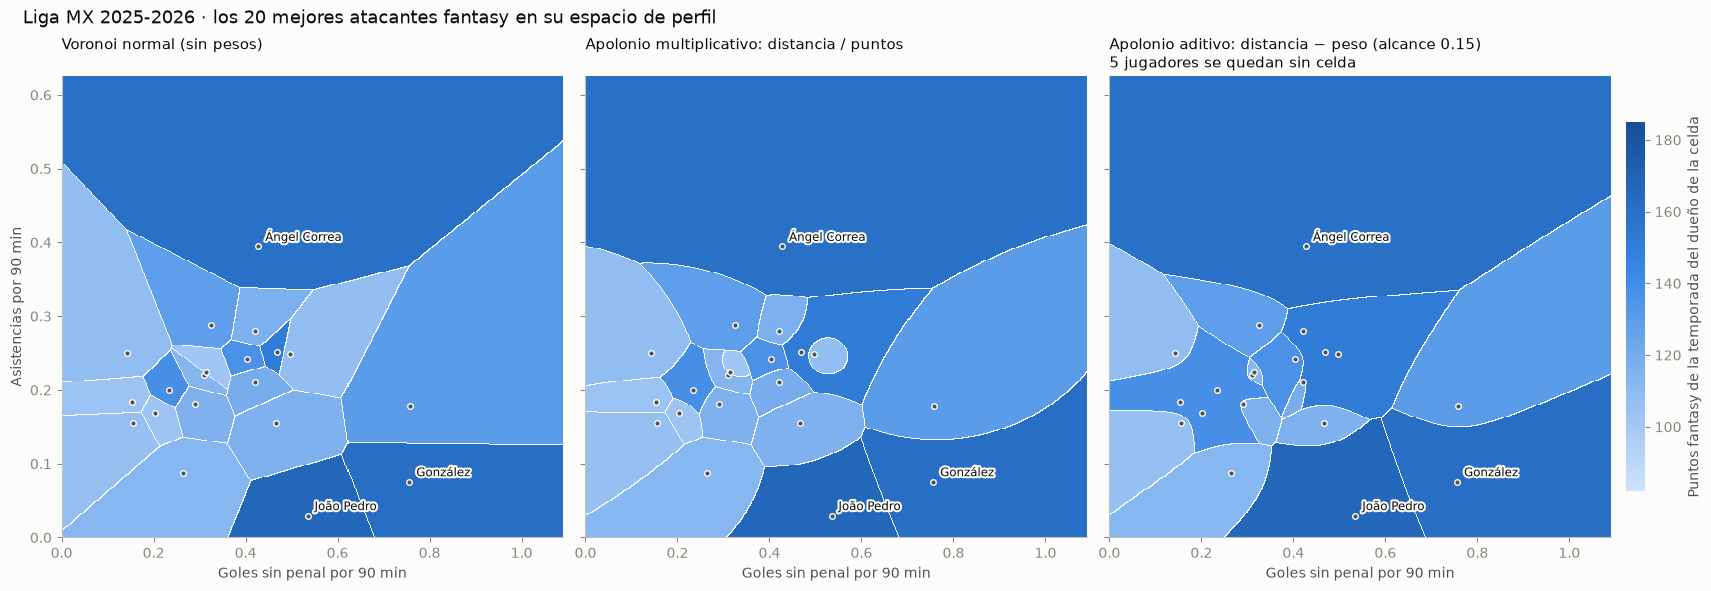

In [11]:
T_EJEMPLO = ULTIMAS[-1]
d = sitios[sitios["temporada_inicio"] == T_EJEMPLO].reset_index(drop=True)
modos = [("voronoi", "Voronoi normal (sin pesos)"),
         ("multiplicativo", "Apolonio multiplicativo: distancia / puntos"),
         ("aditivo", "Apolonio aditivo: distancia − peso (alcance 0.15)")]

fig, axs = plt.subplots(1, 3, figsize=(17, 5.8), sharey=True, constrained_layout=True)
for ax, (modo, titulo) in zip(axs, modos):
    et, xs, ys = celdas(d, modo)
    panel(ax, d, et, xs, ys)
    sin_celda = int((apolonio.areas(et, len(d)) == 0).sum())
    ax.set_title(titulo + (f"\n{sin_celda} jugadores se quedan sin celda" if sin_celda else "\n"), loc="left")
    ax.set_xlabel(ETIQUETA_X)
axs[0].set_ylabel(ETIQUETA_Y)
barra_de_color(fig, axs)
fig.suptitle(f"{LIGA} {d['season'].iloc[0]} · los {N_SITIOS} mejores atacantes fantasy en su espacio de perfil",
             x=0.01, ha="left", fontsize=13, color=TINTA)
fig.savefig(FIGURAS / "fase19_modos_apolonio_ligamx.png", dpi=150)
plt.show()

Lo que cambia de un panel a otro (2025-26):

- **Voronoi normal.** La celda más grande no es la del mejor jugador sino la del perfil más **aislado**: Ángel Correa
  (36% del plano) y Paulinho (19%) están lejos del grupo. Brunetta, rodeado de perfiles parecidos, se queda con 0.4%.
- **Apolonio multiplicativo.** El peso corrige en parte eso. Brunetta (151 pts) sube de 0.4% a 3.8%. Justo a su
  derecha, Gabriel Fernández tiene un perfil casi idéntico (0.50 goles y 0.25 asistencias por 90) pero 107 pts: su
  celda se reduce a un **círculo de Apolonio** (de 4.0% a 0.5%) — la frontera circular que predice la teoría.
  Paulinho baja de 19% a 14%: parte de su espacio era aislamiento, no puntos.
- **Apolonio aditivo.** El efecto del peso es más agresivo: 5 jugadores se quedan sin celda, absorbidos por vecinos
  más fuertes. Con otro `alcance` serían más o menos, y esa dependencia de un parámetro arbitrario es la razón de
  no usarlo como modo principal.

### El mapa temporada por temporada

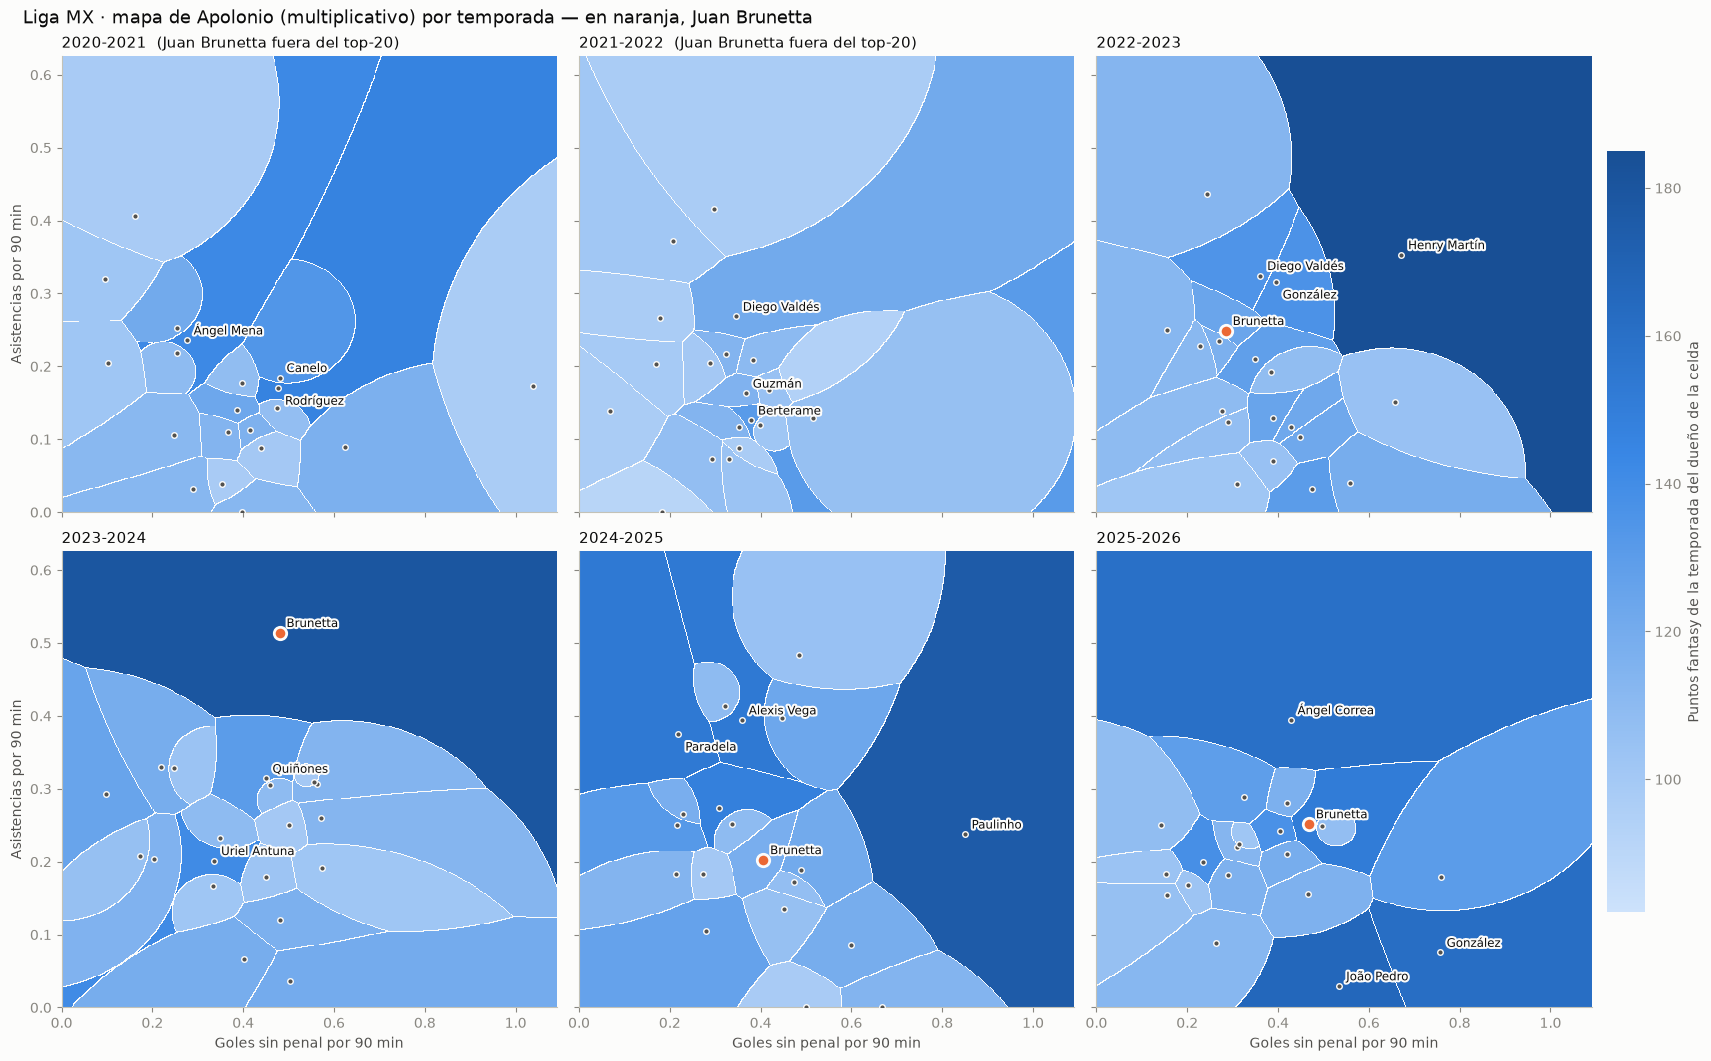

In [12]:
foco = focos.index[0]
fig, axs = plt.subplots(2, 3, figsize=(17, 10.5), sharex=True, sharey=True, constrained_layout=True)
for ax, t in zip(axs.ravel(), ULTIMAS):
    d = sitios[sitios["temporada_inicio"] == t].reset_index(drop=True)
    et, xs, ys = celdas(d)
    panel(ax, d, et, xs, ys, destacar=[foco])
    presente = "" if (d["id_jugador"] == foco).any() else f"  ({focos.loc[foco, 'jugador']} fuera del top-{N_SITIOS})"
    ax.set_title(d["season"].iloc[0] + presente, loc="left")
for ax in axs[1]:
    ax.set_xlabel(ETIQUETA_X)
for ax in axs[:, 0]:
    ax.set_ylabel(ETIQUETA_Y)
barra_de_color(fig, axs)
fig.suptitle(f"{LIGA} · mapa de Apolonio (multiplicativo) por temporada — en naranja, {focos.loc[foco, 'jugador']}",
             x=0.01, ha="left", fontsize=13, color=TINTA)
fig.savefig(FIGURAS / "fase19_apolonio_temporadas_ligamx.png", dpi=150)
plt.show()

Cómo leer la secuencia: cada temporada el plano se reparte de nuevo entre sus 20 mejores atacantes, y el color usa la
misma escala en los seis paneles.

- **2022-23**: Henry Martín (185 pts, el máximo de las 16 temporadas de la liga) domina toda la zona de "goles y
  asistencias a la vez" (43% del plano).
- **2023-24**: Brunetta tiene la tasa de asistencias más alta del top-20 (0.51 por 90) y 179 pts; se queda con toda
  la franja superior (39%).
- **2024-25 y 2025-26**: sigue en el top-20 y con percentil fantasy de 95-99, pero ahora en el centro del grupo,
  rodeado de perfiles parecidos; su celda baja a 1-4%.

Esto adelanta la conclusión de la sección 5: el mapa dice **dónde** está cada jugador respecto a los demás en esa
temporada, no **cuánto** rindió.

## 5. Área de dominio: ¿sirve como medida de rendimiento?

La tentación natural es medir el **área** de la celda de cada jugador (qué fracción del espacio de perfil domina) y
seguirla temporada a temporada. Antes de usarla hay que saber qué mide realmente, porque el área depende de **dos**
cosas:

1. **Rendimiento** (el peso): más puntos → celda más grande.
2. **Aislamiento** (la posición): un perfil raro, lejos de los demás, se queda con mucho espacio aunque tenga pocos
   puntos. Esto pasa incluso en el Voronoi normal, sin pesos.

Para separarlas se calculan tres áreas por jugador-temporada: la de Apolonio (multiplicativo), la del Voronoi normal
(solo aislamiento) y la aditiva. La diferencia **Apolonio − Voronoi** es la "ganancia por rendimiento": cuánto
espacio le da el peso por encima de lo que ya le daba su posición.

In [13]:
filas = []
for temporada, d in sitios.groupby("season", sort=False):
    d = d.reset_index(drop=True)
    area = {modo: apolonio.areas(celdas(d, modo, resolucion=300)[0], len(d))
            for modo in ("multiplicativo", "voronoi", "aditivo")}
    filas.append(d.assign(area_apolonio=area["multiplicativo"], area_voronoi=area["voronoi"],
                          area_aditivo=area["aditivo"]))
tabla_areas = pd.concat(filas, ignore_index=True)
tabla_areas["ganancia_rendimiento"] = tabla_areas["area_apolonio"] - tabla_areas["area_voronoi"]


def spearman_mediano(columna):
    """Correlación de rangos (Spearman) entre `columna` y los puntos, calculada DENTRO de cada temporada (para no
    mezclar temporadas con ambientes distintos) y resumida con la mediana de las 16 temporadas."""
    rhos = [spearmanr(d[columna], d["pts_total"]).statistic for _, d in tabla_areas.groupby("season")]
    return np.median(rhos)


pd.DataFrame({
    "área": ["Voronoi normal", "Apolonio multiplicativo", "Apolonio aditivo", "Ganancia (Apolonio − Voronoi)"],
    "qué refleja": ["solo aislamiento del perfil", "aislamiento + rendimiento", "aislamiento + rendimiento",
                    "lo que agrega el rendimiento"],
    "Spearman con puntos (mediana por temporada)": [
        spearman_mediano(c) for c in ("area_voronoi", "area_apolonio", "area_aditivo", "ganancia_rendimiento")],
}).round(2)

,área,qué refleja,Spearman con puntos (mediana por temporada)
0,Voronoi normal,solo aislamiento del perfil,0.19
1,Apolonio multiplicativo,aislamiento + rendimiento,0.43
2,Apolonio aditivo,aislamiento + rendimiento,0.54
3,Ganancia (Apolonio − Voronoi),lo que agrega el rendimiento,0.61


In [14]:
# Las celdas más grandes de toda la historia de la liga en el panel. Comparar `area_voronoi` (lo que ya tenían por su
# posición) con `area_apolonio` muestra cuánto de su dominio es rendimiento y cuánto es perfil raro.
(tabla_areas.nlargest(8, "area_apolonio")
 [["player", "season", "pts_total", EJE_X, EJE_Y, "area_voronoi", "area_apolonio", "ganancia_rendimiento"]]
 .round(3))

,player,season,pts_total,goals_pens_per90,assists_per90,area_voronoi,area_apolonio,ganancia_rendimiento
80,Dorlan Pabón,2014-2015,159.0,0.612,0.324,0.403,0.508,0.105
240,Henry Martín,2022-2023,185.0,0.671,0.353,0.308,0.435,0.127
302,Ángel Correa,2025-2026,160.0,0.427,0.395,0.360,0.424,0.064
180,Mauro Quiroga,2019-2020,141.0,0.639,0.263,0.174,0.394,0.220
40,Christian Benítez,2012-2013,167.0,0.689,0.157,0.228,0.391,0.163
260,Juan Brunetta,2023-2024,179.0,0.48,0.514,0.264,0.390,0.127
280,Paulinho,2024-2025,175.0,0.849,0.238,0.228,0.340,0.112
121,Ismael Sosa,2016-2017,137.0,0.393,0.285,0.252,0.336,0.084


Tres conclusiones:

1. **El área del Voronoi normal casi no tiene que ver con el rendimiento** (Spearman 0.19): mide qué tan raro es el
   perfil.
2. **Los pesos la acercan al rendimiento** (0.43 multiplicativo, 0.54 aditivo), pero sigue mezclada con el
   aislamiento. Dorlan Pabón 2014-15 tiene la celda más grande de la liga en todo el panel (51%), y 40 de esos 51
   puntos porcentuales ya los tenía sin pesos.
3. **La ganancia (Apolonio − Voronoi) es la que mejor sigue a los puntos** (0.61): es la parte del área que se explica
   por el peso. Entre las celdas más grandes, la de Mauro Quiroga 2019-20 es la que más le debe al peso (+22 puntos
   porcentuales).

### Rendimiento por temporadas: dos lecturas de la misma carrera

Izquierda: el **percentil fantasy** (puntos por jornada, dentro de Liga MX-temporada-posición) — la métrica robusta
para seguir a un jugador. Derecha: su **área de dominio** en el mapa de Apolonio, solo en las temporadas en que entró
al top-20 (por eso hay huecos).

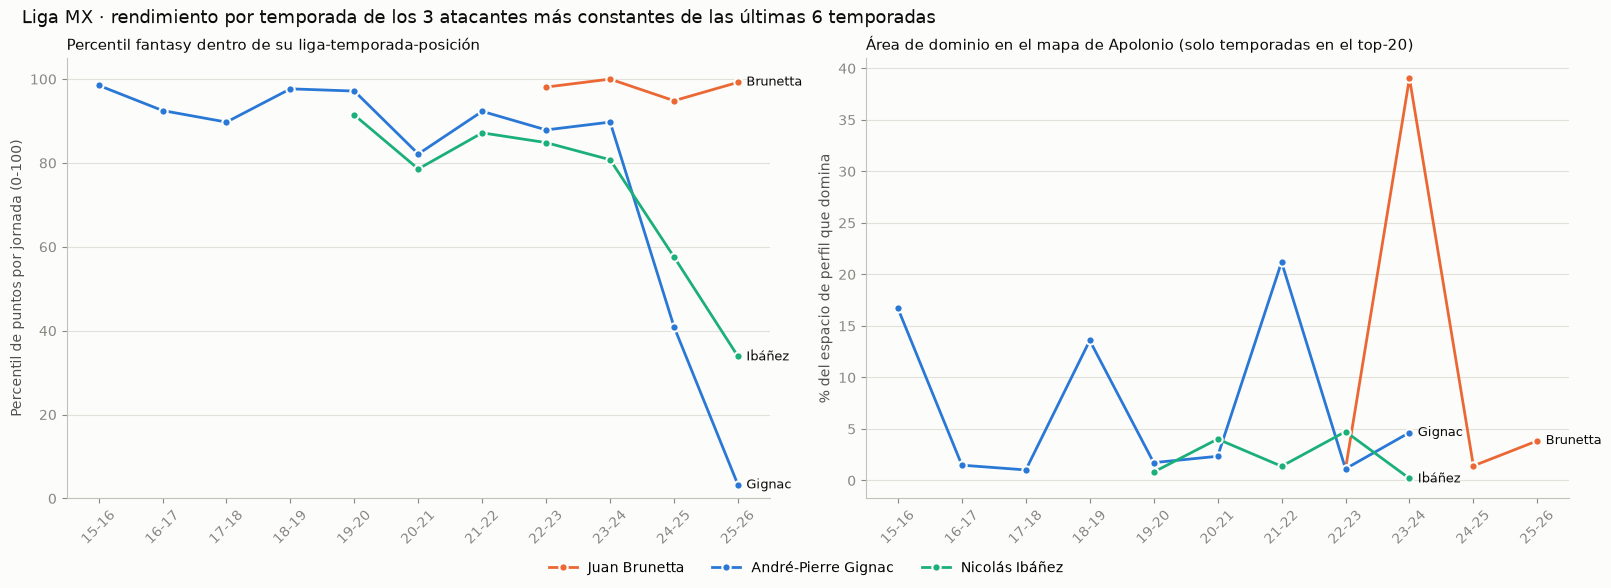

In [15]:
# Eje X: desde la primera temporada elegible de cualquiera de los 3 hasta la última del panel (sin años vacíos).
historial = jt[jt["id_jugador"].isin(COLOR_FOCO) & (jt["league"] == LIGA) & jt["pct_pts_jornada"].notna()]
temporadas = list(range(historial["temporada_inicio"].min(), jt["temporada_inicio"].max() + 1))
fig, (ax_pct, ax_area) = plt.subplots(1, 2, figsize=(16, 5.8), sharex=True, constrained_layout=True)

for id_j, color in COLOR_FOCO.items():
    nombre = focos.loc[id_j, "jugador"]
    # reindex sobre todas las temporadas -> NaN donde no jugó / no calificó, y la línea se corta en vez de unir
    # temporadas no consecutivas como si fueran seguidas.
    pct = (jt[(jt["id_jugador"] == id_j) & (jt["league"] == LIGA)]
           .set_index("temporada_inicio")["pct_pts_jornada"].reindex(temporadas))
    area = (tabla_areas[tabla_areas["id_jugador"] == id_j]
            .set_index("temporada_inicio")["area_apolonio"].reindex(temporadas) * 100)
    for ax, serie in ((ax_pct, pct), (ax_area, area)):
        ax.plot(serie.index, serie.values, color=color, linewidth=2, marker="o", markersize=6,
                markeredgecolor=SUPERFICIE, markeredgewidth=1.5, label=nombre)
        ultimo = serie.last_valid_index()
        ax.annotate(nombre_corto(nombre), (ultimo, serie[ultimo]), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=9, color=TINTA)

ax_pct.set_ylim(0, 105)
ax_pct.set_ylabel("Percentil de puntos por jornada (0-100)")
ax_pct.set_title("Percentil fantasy dentro de su liga-temporada-posición", loc="left")
ax_area.set_ylabel("% del espacio de perfil que domina")
ax_area.set_title(f"Área de dominio en el mapa de Apolonio (solo temporadas en el top-{N_SITIOS})", loc="left")
for ax in (ax_pct, ax_area):
    ax.set_xticks(temporadas)
    ax.set_xticklabels([f"{t % 100:02d}-{(t + 1) % 100:02d}" for t in temporadas], rotation=45)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)
# Leyenda fuera de las gráficas (abajo), para que no tape ninguna línea; además cada línea lleva su nombre al final.
fig.legend(*ax_pct.get_legend_handles_labels(), loc="outside lower center", ncols=3)
fig.suptitle(f"{LIGA} · rendimiento por temporada de los 3 atacantes más constantes de las últimas 6 temporadas",
             x=0.01, ha="left", fontsize=13, color=TINTA)
fig.savefig(FIGURAS / "fase19_rendimiento_temporadas_ligamx.png", dpi=150)
plt.show()

- **Percentil (izquierda): la lectura estable.** Brunetta se mantiene entre 95 y 100 sus cuatro temporadas. Gignac
  (nacido en 1985) estuvo entre 82 y 98 de 2015-16 a 2023-24 y cae a 41 y 3 en sus temporadas de 39 y 40 años.
  Ibáñez baja de 80-91 a 34.
- **Área (derecha): la lectura volátil.** Brunetta pasa de 1% a 39% y de vuelta a 1%, en temporadas en las que su
  percentil apenas se movió (98 → 100 → 95). El área depende de quién más entró al top-20 y de dónde cayó.

**Para seguir el rendimiento de un jugador temporada a temporada, la métrica es el percentil fantasy.** El mapa de
Apolonio sirve para otra cosa: ver, en cada temporada, qué perfiles ofensivos están cubiertos y por quién, y qué
jugadores ocupan un perfil que nadie más con tantos puntos ocupa.

## 6. Conclusiones y siguientes pasos

**El scrapeo de plantillas sirve, con correcciones.** Los errores de la fuente son pocos (unas 80 filas de 61,542) y
todos se corrigen. El problema serio era la **identidad**: se resolvió agregando los ids de FBref a las 112 tablas
(verificadas fila por fila) y corrigiendo los 2 perfiles que FBref tiene duplicados. La comparación mostró que la
clave por nombre juntaba a 4 pares de personas distintas. El otro paso necesario es la **agregación** (2,088
traspasos dentro de la misma liga). La tabla limpia se genera con `python scripts/construir_jugadores_temporada.py` →
`data/processed/jugadores_temporada_2010_2026.csv` (59,452 filas jugador-liga-temporada, 16,307 jugadores), y
la auditoría queda en `output/auditoria_panel_fbref.csv`.

**El fantasy** reproduce las jerarquías conocidas y permite seguir a un jugador con percentiles comparables entre
ligas y épocas. Por ahora es ofensivo: no sirve para defensas ni porteros.

**Apolonio**: el modo multiplicativo es el adecuado (no depende de ninguna constante, y sus fronteras son círculos de
Apolonio verificados por las pruebas). Es una herramienta de **estructura** — quién cubre qué perfil cada temporada —
y no una métrica de rendimiento: el área es volátil y mezcla aislamiento con puntos. Si hace falta un número, la
ganancia Apolonio − Voronoi es la versión más limpia.

### Siguientes pasos, en orden de impacto

1. **Tablas `keepers` y `playingtime` de FBref**: porterías a cero, paradas y goles recibidos con el jugador en cancha
   (`onGA`) completan el fantasy de defensas y porteros. Con los ids de FBref ya se pueden unir sin ambigüedad al
   panel. Primero hay que probar UNA página, porque en la Fase 7 las tablas `passing` y `defense` resultaron vacías.
2. **Temporada en curso (2026-27, parcial)**, para conectar esto con el seguimiento en vivo del dashboard.
3. **Apolonio en la cancha**: con datos de eventos (StatsBomb Open Data, notebook 01) se puede hacer la versión
   espacial — la posición media del jugador como sitio y su rendimiento como peso.
4. **Otras ligas**: todo está parametrizado por `LIGA`; con `LIGA = "Premier League"` se regeneran las figuras.